# 4 — Reusable Project Template: Univariate Time Series Forecasting

Copy this notebook for a **new** forecasting project. Edit only the `CONFIG` cell and the "Load your data" cell — the rest of the pipeline is generic and should run unchanged for any single numeric column indexed by time.

**Pipeline stages:** Load → EDA → Stationarity/Seasonality → Order Search → Fit → Diagnose → Backtest vs. Naive Baselines → Final Forecast → Write-up.


In [1]:
# ============== CONFIG — edit this cell for your project ==============
CONFIG = {
    "csv_path": "COCO_COLA.csv",     # set to None if loading data another way
    "date_col": "Date",
    "value_col": "Open",
    "start_date": "2016-01-01",       # None to use the whole series
    "end_date": None,
    "resample_rule": "M",             # e.g. 'D','W','M','Q','Y'; None to keep native frequency
    "seasonal_period_guess": 12,      # None if you don't expect seasonality; else an integer period
    "test_horizon": 24,               # number of periods held out for backtesting
    "adf_maxlag": 25,                 # generous maxlag for the Dickey-Fuller test
    "max_ar_search": 6,
    "max_ma_search": 3,
    "random_seed": 42,
}
# ========================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, arma_order_select_ic
from statsmodels.tsa.arima.model import ARIMA
import pmdarima as pm
from pmdarima.model_selection import train_test_split as pm_train_test_split
from sklearn.metrics import mean_squared_error
import math

np.random.seed(CONFIG["random_seed"])


## Stage 1 — Load data
Replace the body of this cell with however you actually load your series; everything downstream only needs a single-column `pandas.Series` called `series`, indexed by a `DatetimeIndex`.

In [2]:
raw = pd.read_csv(CONFIG["csv_path"], parse_dates=[CONFIG["date_col"]], index_col=CONFIG["date_col"])
series = raw[CONFIG["value_col"]].copy()

if CONFIG["start_date"] is not None:
    series = series[series.index >= CONFIG["start_date"]]
if CONFIG["end_date"] is not None:
    series = series[series.index <= CONFIG["end_date"]]
if CONFIG["resample_rule"] is not None:
    series = series.resample(CONFIG["resample_rule"]).mean()

series = series.dropna()
print(series.shape)
series.head()


(72,)


/tmp/ipykernel_650/3416723197.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  series = series.resample(CONFIG["resample_rule"]).mean()


Date
2016-01-31    41.951053
2016-02-29    43.113000
2016-03-31    44.944546
2016-04-30    45.712381
2016-05-31    44.893809
Freq: ME, Name: Open, dtype: float64

## Stage 2 — Exploratory plots (series, ACF, PACF)

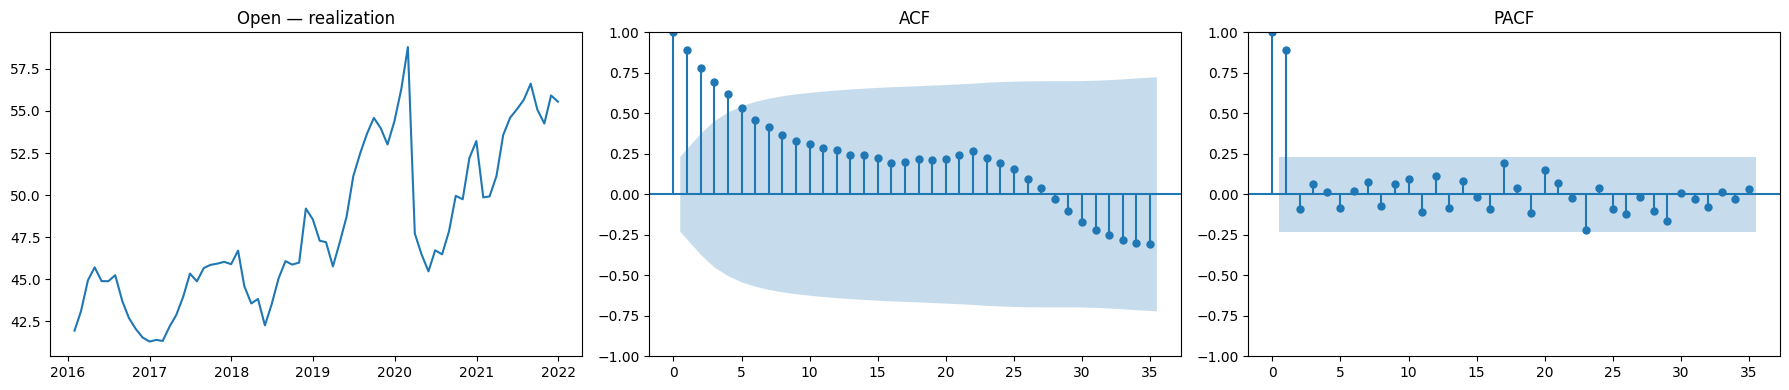

Look for: (a) slow ACF decay -> trend/unit root; (b) a repeating spike every s lags -> seasonality of period s.


In [3]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
ax[0].plot(series.index, series.values); ax[0].set_title(f'{CONFIG["value_col"]} — realization')
n_lags = min(40, len(series) // 2 - 1)
plot_acf(series.values, alpha=0.05, lags=n_lags, ax=ax[1]); ax[1].set_title('ACF')
plot_pacf(series.values, alpha=0.05, lags=n_lags, ax=ax[2]); ax[2].set_title('PACF')
plt.tight_layout(); plt.show()

print("Look for: (a) slow ACF decay -> trend/unit root; (b) a repeating spike every s lags -> seasonality of period s.")


## Stage 3 — Stationarity check, differencing, and (optional) seasonal differencing

In [4]:
def adf_report(x, label, maxlag=CONFIG["adf_maxlag"]):
    stat, pval, *_ , crit = adfuller(x, maxlag=maxlag, regression='c')[:5]
    print(f"[{label}] ADF stat={stat:.4f}  p-value={pval:.4g}  5% critical={crit['5%']:.4f}  "
          f"-> {'STATIONARY (reject H0)' if pval < 0.05 else 'NON-STATIONARY (fail to reject H0)'}")
    return pval

y = series.values.astype(float)
d = 0
D = 0
working = y.copy()

# Optional seasonal differencing first, if you suspect seasonality
if CONFIG["seasonal_period_guess"]:
    s = CONFIG["seasonal_period_guess"]
    seasonal_diff = pm.utils.diff(working, lag=s)
    p_before = adf_report(working, "before seasonal diff")
    p_after = adf_report(seasonal_diff, f"after seasonal diff (lag={s})")
    if p_after < p_before:
        print(f"Applying seasonal difference at lag {s} (D=1).")
        working = seasonal_diff
        D = 1
    else:
        print("Seasonal difference did not clearly help; keeping D=0. Re-inspect the ACF if you expected seasonality.")

# Sequential (trend) differencing until stationary, capped at d=2 as a sanity limit
pval = adf_report(working, f"d={d}")
while pval >= 0.05 and d < 2:
    working = np.diff(working, n=1)
    d += 1
    pval = adf_report(working, f"d={d}")

print(f"\nSelected: d={d}, D={D} (seasonal period {CONFIG['seasonal_period_guess'] if D else 'n/a'})")
stationary_series = working


[before seasonal diff] ADF stat=-1.5326  p-value=0.5173  5% critical=-2.9032  -> NON-STATIONARY (fail to reject H0)
[after seasonal diff (lag=12)] ADF stat=-0.6848  p-value=0.8507  5% critical=-2.9512  -> NON-STATIONARY (fail to reject H0)
Seasonal difference did not clearly help; keeping D=0. Re-inspect the ACF if you expected seasonality.
[d=0] ADF stat=-1.5326  p-value=0.5173  5% critical=-2.9032  -> NON-STATIONARY (fail to reject H0)
[d=1] ADF stat=-7.8454  p-value=5.789e-12  5% critical=-2.9038  -> STATIONARY (reject H0)

Selected: d=1, D=0 (seasonal period n/a)


/tmp/ipykernel_650/3697705772.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  stat, pval, *_ , crit = adfuller(x, maxlag=maxlag, regression='c')[:5]
/tmp/ipykernel_650/3697705772.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  stat, pval, *_ , crit = adfuller(x, maxlag=maxlag, regression='c')[:5]
/tmp/ipykernel_650/3697705772.py:2: FutureWarning: adfuller currentl

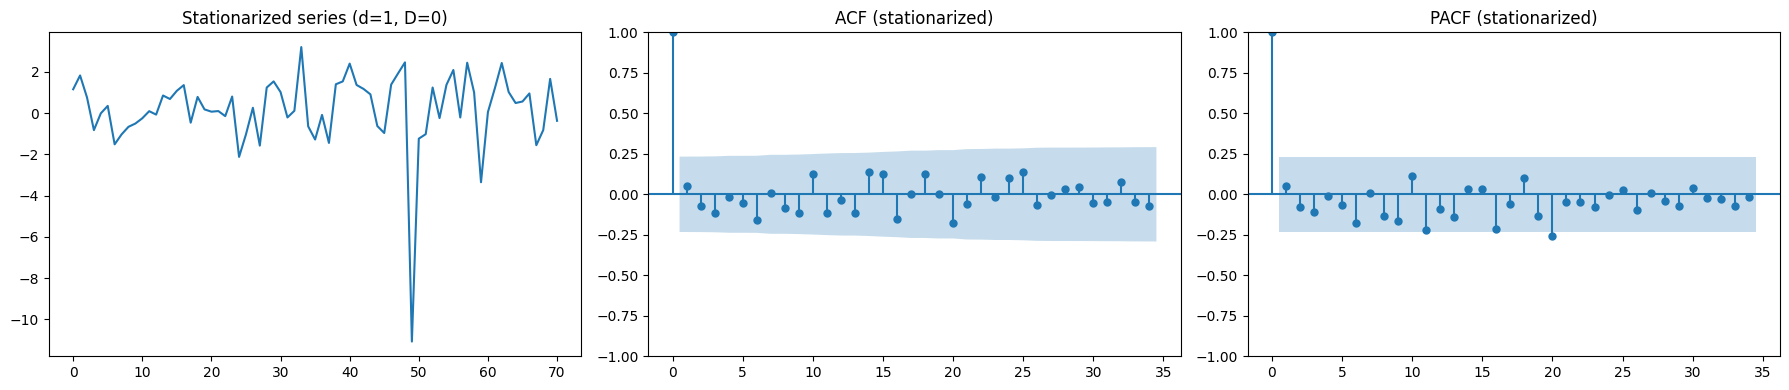

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
ax[0].plot(stationary_series); ax[0].set_title(f'Stationarized series (d={d}, D={D})')
n_lags2 = min(40, len(stationary_series) // 2 - 1)
plot_acf(stationary_series, alpha=0.05, lags=n_lags2, ax=ax[1]); ax[1].set_title('ACF (stationarized)')
plot_pacf(stationary_series, alpha=0.05, lags=n_lags2, ax=ax[2]); ax[2].set_title('PACF (stationarized)')
plt.tight_layout(); plt.show()


## Stage 4 — Order search on the stationarized series

In [6]:
order_search = arma_order_select_ic(
    y=stationary_series,
    max_ar=CONFIG["max_ar_search"],
    max_ma=CONFIG["max_ma_search"],
    ic=['aic', 'bic'],
    trend='n'
)
print('AIC order (p,q):', order_search.aic_min_order, '| AIC:', round(order_search.aic.min().min(), 3))
print('BIC order (p,q):', order_search.bic_min_order, '| BIC:', round(order_search.bic.min().min(), 3))

# Candidate full orders for the ORIGINAL series (adding back d)
p_aic, q_aic = order_search.aic_min_order
p_bic, q_bic = order_search.bic_min_order
candidates = {
    "AIC": (p_aic, d, q_aic),
    "BIC": (p_bic, d, q_bic),
}
print("Candidate ARIMA(p,d,q) orders:", candidates)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible sta

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters f

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


AIC order (p,q): (np.int64(0), np.int64(0)) | AIC: 289.367
BIC order (p,q): (np.int64(0), np.int64(0)) | BIC: 291.629
Candidate ARIMA(p,d,q) orders: {'AIC': (np.int64(0), 1, np.int64(0)), 'BIC': (np.int64(0), 1, np.int64(0))}


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


## Stage 5 — Fit candidate models and compare (coefficient significance + AIC/BIC)

In [7]:
fitted_models = {}
for name, order in candidates.items():
    try:
        m = ARIMA(y, order=order, enforce_stationarity=True, enforce_invertibility=True).fit()
        fitted_models[name] = m
        print(f"--- {name} candidate: ARIMA{order} ---")
        print(m.summary())
        print()
    except Exception as e:
        print(f"{name} candidate ARIMA{order} failed to fit: {e}")


--- AIC candidate: ARIMA(np.int64(0), 1, np.int64(0)) ---
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   72
Model:                 ARIMA(0, 1, 0)   Log Likelihood                -143.683
Date:                Fri, 28 Aug 2026   AIC                            289.367
Time:                        20:28:12   BIC                            291.629
Sample:                             0   HQIC                           290.266
                                 - 72                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         3.3519      0.185     18.115      0.000       2.989       3.715
Ljung-Box (L1) (Q):                   0.19   Jarque-Bera (JB):           

**Model-selection rule of thumb:** prefer the model whose coefficients are (mostly) statistically significant (95% CI excludes 0) over the model with the lowest AIC/BIC if the lowest-error model has non-significant terms — that is a classic overfitting signature (see Background notebook, Part 7).

In [8]:
# TODO once you've read the summaries above: set this to the dict key ('AIC' or 'BIC') you're choosing to carry forward
chosen_model_name = "BIC"
final_model = fitted_models[chosen_model_name]
final_order = candidates[chosen_model_name]
print("Chosen model:", chosen_model_name, final_order)


Chosen model: BIC (np.int64(0), 1, np.int64(0))


## Stage 6 — Backtest: held-out forecast vs. actuals

ARIMA(np.int64(0), 1, np.int64(0)) backtest RMSE: 4.4914


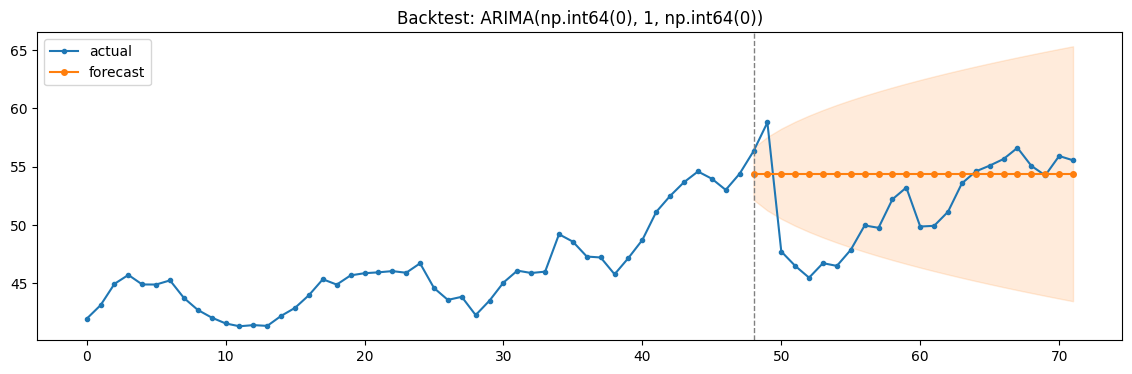

In [9]:
h = CONFIG["test_horizon"]
n = len(y)
train_y, test_y = y[: n - h], y[n - h:]

backtest_model = ARIMA(train_y, order=final_order, enforce_stationarity=True, enforce_invertibility=True).fit()
df_pred = backtest_model.get_prediction(start=len(train_y), end=n - 1).summary_frame(alpha=0.05)
df_pred.index = range(len(train_y), n)

rmse_model = math.sqrt(mean_squared_error(test_y, df_pred['mean'].values))
print(f"ARIMA{final_order} backtest RMSE: {rmse_model:.4f}")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(range(n), y, marker='o', ms=3, label='actual')
ax.plot(df_pred.index, df_pred['mean'], marker='o', ms=4, color='C1', label='forecast')
ax.fill_between(df_pred.index, df_pred['mean_ci_lower'], df_pred['mean_ci_upper'], color='C1', alpha=0.15)
ax.axvline(len(train_y), color='gray', linestyle='--', linewidth=1)
ax.legend(); ax.set_title(f'Backtest: ARIMA{final_order}'); plt.show()


## Stage 7 — Compare against naive baselines (persistence & rolling window)

Best persistence: p=1, RMSE=2.7157
Best rolling window: w=1, RMSE=2.7157
ARIMA(np.int64(0), 1, np.int64(0)) RMSE=4.4914


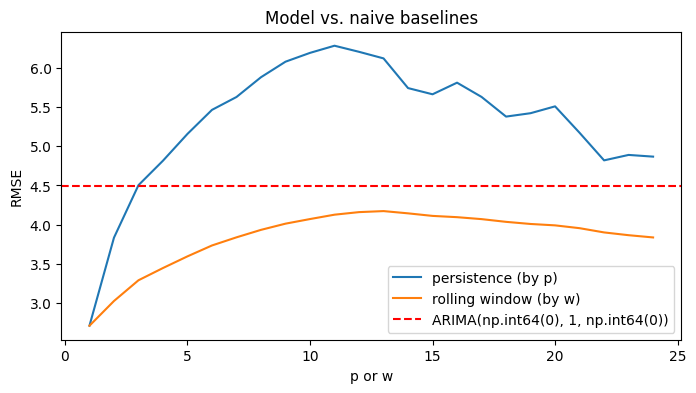


Winner by RMSE: persistence (2.7157)


In [10]:
def persistence_rmse_curve(train, test, max_p):
    scores = []
    for p in range(1, max_p + 1):
        history = list(train)
        preds = []
        for i in range(len(test)):
            preds.append(history[-p])
            history.append(test[i])
        scores.append(math.sqrt(mean_squared_error(test, preds)))
    return scores

def rolling_rmse_curve(train, test, max_w):
    scores = []
    for w in range(1, max_w + 1):
        history = list(train)
        preds = []
        for i in range(len(test)):
            preds.append(np.mean(history[-w:]))
            history.append(test[i])
        scores.append(math.sqrt(mean_squared_error(test, preds)))
    return scores

max_k = min(h, max(2, len(train_y) - 1))
persistence_scores = persistence_rmse_curve(train_y, test_y, max_k)
rolling_scores = rolling_rmse_curve(train_y, test_y, max_k)

best_p = int(np.argmin(persistence_scores)) + 1
best_w = int(np.argmin(rolling_scores)) + 1
best_persistence_rmse = min(persistence_scores)
best_rolling_rmse = min(rolling_scores)

print(f"Best persistence: p={best_p}, RMSE={best_persistence_rmse:.4f}")
print(f"Best rolling window: w={best_w}, RMSE={best_rolling_rmse:.4f}")
print(f"ARIMA{final_order} RMSE={rmse_model:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, max_k + 1), persistence_scores, label='persistence (by p)')
ax.plot(range(1, max_k + 1), rolling_scores, label='rolling window (by w)')
ax.axhline(rmse_model, color='red', linestyle='--', label=f'ARIMA{final_order}')
ax.set_xlabel('p or w'); ax.set_ylabel('RMSE'); ax.legend(); ax.set_title('Model vs. naive baselines')
plt.show()

winner = min([("ARIMA", rmse_model), ("persistence", best_persistence_rmse), ("rolling", best_rolling_rmse)], key=lambda t: t[1])
print(f"\nWinner by RMSE: {winner[0]} ({winner[1]:.4f})")


## Stage 8 — Final forecast beyond observed data (refit on full series)

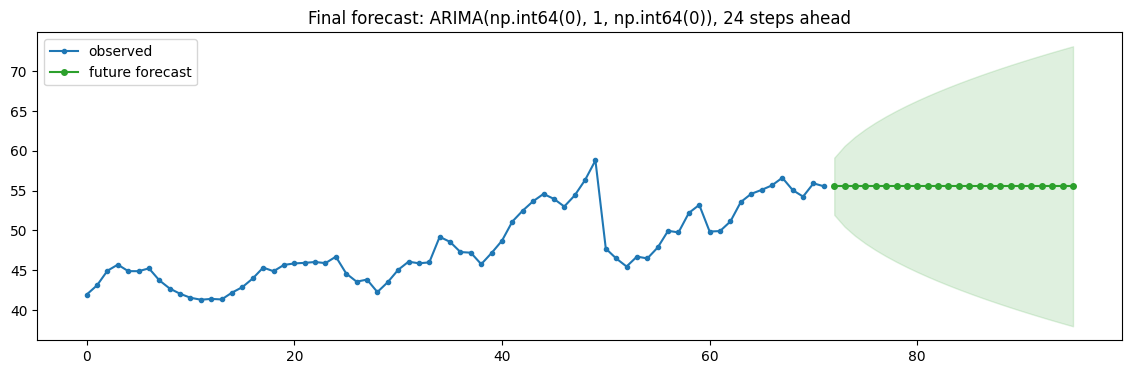

In [11]:
forecast_horizon = h  # change if you want a different future horizon than the backtest window
df_future = final_model.get_prediction(start=n, end=n + forecast_horizon - 1).summary_frame(alpha=0.05)
df_future.index = range(n, n + forecast_horizon)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(range(n), y, marker='o', ms=3, label='observed')
ax.plot(df_future.index, df_future['mean'], marker='o', ms=4, color='C2', label='future forecast')
ax.fill_between(df_future.index, df_future['mean_ci_lower'], df_future['mean_ci_upper'], color='C2', alpha=0.15)
ax.legend(); ax.set_title(f'Final forecast: ARIMA{final_order}, {forecast_horizon} steps ahead'); plt.show()


## Stage 9 — Write-up (fill in for your project)

- **Series & source:**
- **Frequency / resampling used:**
- **Chosen order (p,d,q) and why (vs. the other candidate):**
- **Backtest RMSE vs. best naive baseline — did the model earn its complexity?**
- **Diagnostics (Ljung-Box / Jarque-Bera / Heteroskedasticity) — any red flags?**
- **Known limitations for this specific series (structural breaks in range? volatility clustering? short history?):**
- **Recommended next step (exogenous variables / GARCH-family variance model / different horizon / more data):**
